In [234]:
import torch
from utils import solve_riccati
import numpy as np
from network import PhiNetwork
from utils import batched_jacobian
import matplotlib.pyplot as plt

In [235]:
phi_net = PhiNetwork(input_dim=2+1, out_dim=2, hidden_dim=32)
phi_net.load_state_dict(torch.load('data/phi_network_linear_bsde_stableA_nl0.0.pth'))

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_82912/1224312850.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  phi_net.load_state_dict(torch.load('data/phi_

<All keys matched successfully>

In [236]:
A = np.array([[0.0, 1.0], [-1.0, -0.5]])
B = np.array([[1.0, 0.0], [0.0, 1.0]])
Q_f = np.array([[1.0, 0.0], [0.0, 1.0]])
T = 4.0
dt = 0.005

In [237]:
G_ref = solve_riccati(A, Q_f, T, dt, dim=2)

In [238]:
steps = int(T/dt)
time_grid = torch.arange(0, steps+1) * dt

In [239]:
partial_phi_record = torch.zeros((steps+1, 1000, 2, 2))
for i in range(steps+1):
    X = torch.randn(1000, 2)
    X.requires_grad = True
    phi_values = phi_net(X, torch.tensor(i * dt).repeat(X.shape[0], 1))
    partial_phi_values = batched_jacobian(phi_values, X)
    partial_phi_record[i] = partial_phi_values

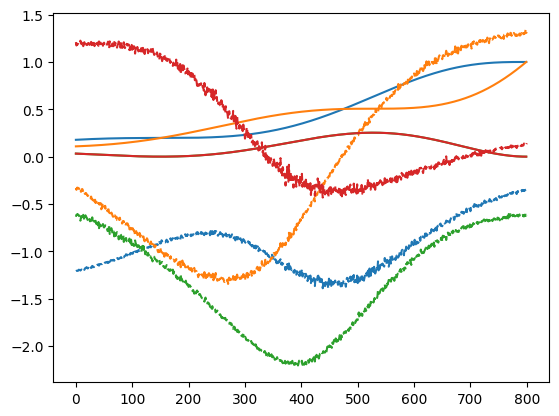

In [240]:
plt.figure()
plt.plot(G_ref[0, 0, :], color='C0')
plt.plot(partial_phi_record[:, :, 0, 0].mean(dim=1).detach().numpy(), '--', color='C0')
plt.plot(G_ref[1, 1, :], color='C1')
plt.plot(partial_phi_record[:, :, 1, 1].mean(dim=1).detach().numpy(), '--', color='C1')
plt.plot(G_ref[0, 1, :], color='C2')
plt.plot(partial_phi_record[:, :, 0, 1].mean(dim=1).detach().numpy(), '--', color='C2')
plt.plot(G_ref[1, 0, :], color='C3')
plt.plot(partial_phi_record[:, :, 1, 0].mean(dim=1).detach().numpy(), '--', color='C3')


In [252]:
nl_list = [0.0, 0.3, 0.5, 0.7, 1.0, 2.0]
grad_theta_list = []
theta_value_list = []
phi_list = []

In [253]:
for nl in nl_list:
    grad_theta_list.append(torch.load(f'data/initial_theta_grad_stableA_nl{nl}.pth'))
    theta_value_list.append(torch.load(f'data/initial_theta_value_stableA_nl{nl}.pth'))
    phi_list.append(torch.load(f'data/phi_network_linear_bsde_stableA_nl{nl}.pth'))

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_82912/2116359504.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  grad_theta_list.append(torch.load(f'data/init

In [254]:
MSE_AD = []
MSE_BSDE = []
for i, nl in enumerate(nl_list):
    gradient = grad_theta_list[i]  ### Y_0
    theta = theta_value_list[i]  ### Y_0
    phi_net.load_state_dict(phi_list[i])

    Y_NN = phi_net(theta, torch.tensor(0.0).repeat(theta.shape[0], 1))
    Y_exact = theta @ torch.tensor(G_ref[:, :, 0], dtype=torch.float32).T

    MSE_gradient = torch.mean((gradient - Y_exact) ** 2).item()
    MSE_NN = torch.mean((Y_NN - Y_exact) ** 2).item()

    MSE_AD.append(MSE_gradient)
    MSE_BSDE.append(MSE_NN)

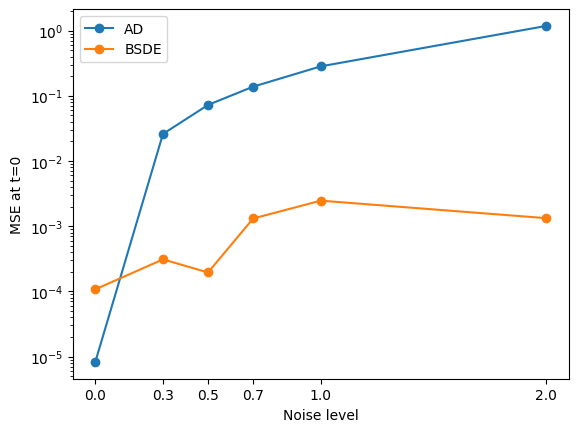

In [255]:
plt.figure()
plt.plot(nl_list, MSE_AD, '-o', label='AD')
plt.plot(nl_list, MSE_BSDE, '-o', label='BSDE')
plt.xticks(nl_list)
plt.yscale('log')
plt.xlabel('Noise level')
plt.ylabel('MSE at t=0')
plt.legend()
plt.show()

In [245]:
# gradient = torch.load('data/initial_theta_grad_nonoise.pth') ### Y_0

In [246]:
# theta = torch.load('data/initial_theta_value_nonoise.pth') ### Y_0

In [247]:
# Y_NN = phi_net(theta, torch.tensor(0.0).repeat(theta.shape[0], 1))

In [248]:
# Y_exact = theta @ torch.tensor(G_ref[:, :, 0], dtype=torch.float32).T

In [249]:
# MSE_gradient = torch.mean((gradient - Y_exact) ** 2).item()
# MSE_NN = torch.mean((Y_NN - Y_exact) ** 2).item()

In [250]:
# MSE_gradient

In [251]:
# MSE_NN